In [1]:
import os
from PIL import Image
import torch
from torchvision import transforms

data_dir = 'pythia/Pythia'

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

# Dictionary to hold lists of images for each class
images_by_class = {}

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        images_by_class[class_name] = []
        for file_name in os.listdir(class_path):
            file_path = os.path.join(class_path, file_name)
            try:
                # Load image, transform it, and add to the list
                with Image.open(file_path) as img:
                    img_tensor = transform(img)
                    images_by_class[class_name].append(img_tensor)
            except Exception as e:
                # Skip files that aren't images
                pass

for class_name, images in images_by_class.items():
    print(f"Class '{class_name}': {len(images)} images")


Class 'attack_a': 1000 images
Class 'attack_b': 1000 images
Class 'attack_c': 1000 images
Class 'attack_d': 1000 images
Class 'attack_e': 1000 images
Class 'attack_f': 1000 images
Class 'attack_g': 1000 images
Class 'attack_h': 1000 images
Class 'clean': 1000 images


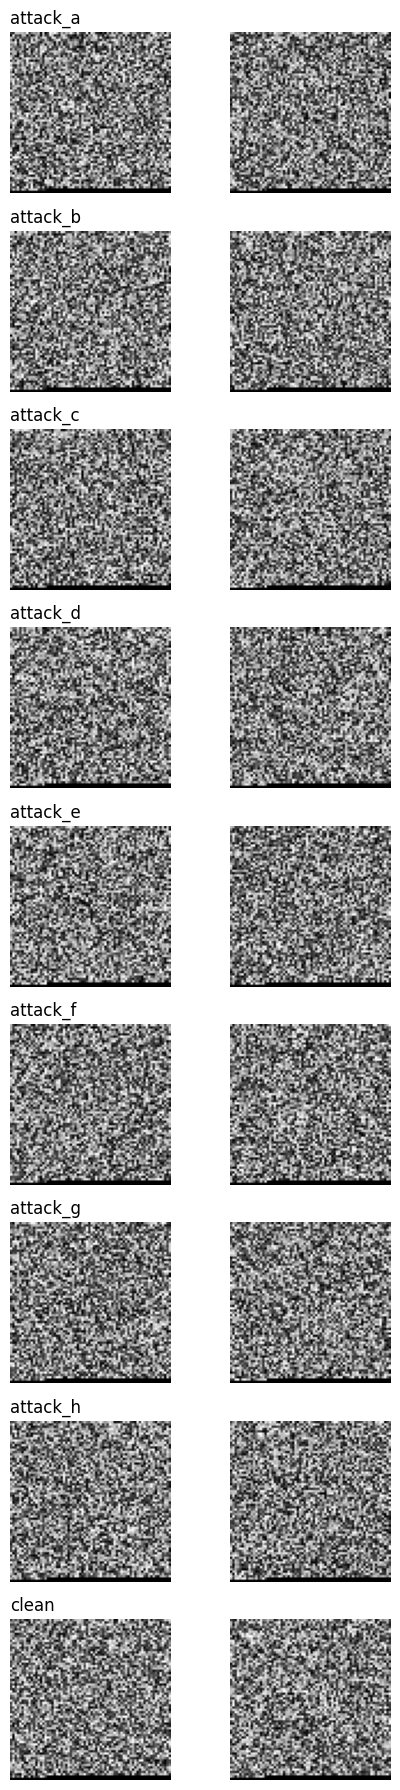

In [2]:
import matplotlib.pyplot as plt

examples_per_class = 2

# Plot the examples
num_classes = len(images_by_class)
if num_classes > 0:
    fig, axes = plt.subplots(num_classes, examples_per_class, figsize=(5, 2 * num_classes))
    
    # Ensure axes is 2D array
    if num_classes == 1:
        axes = [axes]
    
    for i, (class_name, images) in enumerate(images_by_class.items()):
        for j in range(examples_per_class):
            if num_classes == 1:
                ax = axes[j]
            elif examples_per_class == 1:
                ax = axes[i]
            else:
                ax = axes[i][j]
                
            if j < len(images):
                image = images[j]
                # Convert tensor to numpy and remove channel dimension for grayscale
                img_np = image.squeeze().numpy() 
                
                ax.imshow(img_np, cmap='gray')
            ax.axis('off')
            
            if j == 0:
                ax.set_title(class_name, loc='left')

    plt.tight_layout()
    plt.show()
else:
    print("No images found to display.")


In [3]:
import random
import torch
from torch.utils.data import TensorDataset

def create_datasets(clean_dict, attack_dicts, test_ratio=0.2):
    """
    Creates train and test datasets from clean and attack dictionaries.
    Assigns label 0 to clean images and label 1 to attack images.
    Randomly splits each dictionary into 80% train and 20% test datasets.
    """
    train_images = []
    train_labels = []
    test_images = []
    test_labels = []
    
    def process_and_split(data_dict, label):
        # Gather all images from the current dictionary
        all_images = []
        for class_name, images in data_dict.items():
            all_images.extend(images)
            
        # Shuffle images to ensure random selection for test set
        random.shuffle(all_images)
        
        # Calculate split index
        split_idx = int(len(all_images) * (1 - test_ratio))
        
        # Split into training and testing lists
        train_images.extend(all_images[:split_idx])
        train_labels.extend([label] * split_idx)
        
        test_images.extend(all_images[split_idx:])
        test_labels.extend([label] * (len(all_images) - split_idx))

    # Process the clean dictionary with label 0
    process_and_split(clean_dict, 0)
    
    # Process each attack dictionary with label 1
    for attack_dict in attack_dicts:
        process_and_split(attack_dict, 1)
        
    # Convert lists to stacked PyTorch tensors and into TensorDatasets
    train_dataset = None
    if train_images:
        train_dataset = TensorDataset(
            torch.stack(train_images), 
            torch.tensor(train_labels, dtype=torch.long)
        )
        
    test_dataset = None
    if test_images:
        test_dataset = TensorDataset(
            torch.stack(test_images), 
            torch.tensor(test_labels, dtype=torch.long)
        )
        
    return train_dataset, test_dataset


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import pytorch_lightning as pl

class VariableCNN(pl.LightningModule):
    def __init__(self, size='medium', lr=1e-4, dropout_rate1=0.0, dropout_rate2=0.0, optimizer_name='adam'):
        super().__init__()
        self.save_hyperparameters()
        self.size = size
        self.optimizer_name = optimizer_name.lower()
        
        if size == 'small':
            self.features = nn.Sequential(
                nn.Conv2d(1, 8, kernel_size=3, padding=1),
                nn.GELU(),
                nn.MaxPool2d(2),
                
                nn.Conv2d(8, 16, kernel_size=3, padding=1),
                nn.GELU(),
                nn.AdaptiveMaxPool2d((4, 4)), 
            )
            fc_in = 16 * 4 * 4
            fc_hidden = 32
            
        elif size == 'medium_light':
            self.features = nn.Sequential(
                nn.Conv2d(1, 8, kernel_size=3, padding=1),
                nn.GELU(),
                nn.MaxPool2d(2),
                
                nn.Conv2d(8, 16, kernel_size=3, padding=1),
                nn.GELU(),
                nn.MaxPool2d(2),
                
                nn.Conv2d(16, 32, kernel_size=3, padding=1),
                nn.GELU(),
                nn.AdaptiveMaxPool2d((4, 4)), 
            )
            fc_in = 32 * 4 * 4
            fc_hidden = 32
            
        elif size == 'medium_bn':
            self.features = nn.Sequential(
                nn.Conv2d(1, 16, kernel_size=3, padding=1),
                nn.BatchNorm2d(16),
                nn.GELU(),
                nn.MaxPool2d(2),
                
                nn.Conv2d(16, 32, kernel_size=3, padding=1),
                nn.BatchNorm2d(32),
                nn.GELU(),
                nn.MaxPool2d(2),
                
                nn.Conv2d(32, 64, kernel_size=3, padding=1),
                nn.BatchNorm2d(64),
                nn.GELU(),
                nn.AdaptiveMaxPool2d((4, 4)), 
            )
            fc_in = 64 * 4 * 4
            fc_hidden = 64
            
        elif size == 'large':
            self.features = nn.Sequential(
                nn.Conv2d(1, 32, kernel_size=3, padding=1),
                nn.GELU(),
                nn.MaxPool2d(2),
                
                nn.Conv2d(32, 64, kernel_size=3, padding=1),
                nn.GELU(),
                nn.MaxPool2d(2),
                
                nn.Conv2d(64, 128, kernel_size=3, padding=1),
                nn.GELU(),
                nn.MaxPool2d(2),
                
                nn.Conv2d(128, 256, kernel_size=3, padding=1),
                nn.GELU(),
                nn.AdaptiveMaxPool2d((4, 4)), 
            )
            fc_in = 256 * 4 * 4
            fc_hidden = 128
            
        else: # medium
            self.features = nn.Sequential(
                nn.Conv2d(1, 16, kernel_size=3, padding=1),
                nn.GELU(),
                nn.MaxPool2d(2),
                
                nn.Conv2d(16, 32, kernel_size=3, padding=1),
                nn.GELU(),
                nn.MaxPool2d(2),
                
                nn.Conv2d(32, 64, kernel_size=3, padding=1),
                nn.GELU(),
                nn.AdaptiveMaxPool2d((4, 4)), 
            )
            fc_in = 64 * 4 * 4
            fc_hidden = 64
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(fc_in, fc_hidden),
            nn.GELU(),
            nn.Dropout(dropout_rate1),
            nn.Linear(fc_hidden, max(fc_hidden // 2, 16)),
            nn.GELU(),
            nn.Dropout(dropout_rate2),
            nn.Linear(max(fc_hidden // 2, 16), 1), 
        )
        
        self.criterion = nn.BCEWithLogitsLoss()

    def forward(self, x):
        return self.classifier(self.features(x))
        
    def _shared_step(self, batch, batch_idx, step_name):
        images, labels = batch
        labels = labels.float().unsqueeze(1)
        outputs = self(images)
        
        loss = self.criterion(outputs, labels)
        
        predictions = (outputs > 0).float()
        acc = (predictions == labels).float().mean()
        
        self.log(f"{step_name}_loss", loss, prog_bar=True)
        self.log(f"{step_name}_acc", acc, prog_bar=True)
        
        return loss

    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, batch_idx, "train")

    def validation_step(self, batch, batch_idx):
        return self._shared_step(batch, batch_idx, "val")

    def test_step(self, batch, batch_idx):
        return self._shared_step(batch, batch_idx, "test")

    def configure_optimizers(self):
        if self.optimizer_name == 'adam':
            optimizer = optim.Adam(self.parameters(), lr=self.hparams.lr)
        elif self.optimizer_name == 'adamw':
            optimizer = optim.AdamW(self.parameters(), lr=self.hparams.lr)
        elif self.optimizer_name == 'sgd':
            optimizer = optim.SGD(self.parameters(), lr=self.hparams.lr, momentum=0.9)
        elif self.optimizer_name == 'rmsprop':
            optimizer = optim.RMSprop(self.parameters(), lr=self.hparams.lr)
        else:
            optimizer = optim.Adam(self.parameters(), lr=self.hparams.lr)
        return optimizer

def train_model(train_dataset, epochs=5, batch_size=32, lr=1e-4, dropout_rate1=0.0, dropout_rate2=0.0, size='medium', optimizer_name='adam'):
    model = VariableCNN(size=size, lr=lr, dropout_rate1=dropout_rate1, dropout_rate2=dropout_rate2, optimizer_name=optimizer_name)
    
    # Split train_dataset into train (80%) and validation (20%)
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_split, val_split = random_split(train_dataset, [train_size, val_size])
    
    train_loader = DataLoader(train_split, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_split, batch_size=batch_size, shuffle=False, num_workers=0)
    
    trainer = pl.Trainer(
        max_epochs=epochs,
        accelerator='auto',
        devices='auto',
        enable_progress_bar=False, # Disable massive progress bars for the grid search
        logger=False # Disable logger for grid search to keep output clean
    )
    
    trainer.fit(model, train_loader, val_loader)
    
    return model, trainer


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def evaluate_and_plot(model, trainer, test_dataset, batch_size=32):
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    # Run test loop if you want lightning to log test metrics
    trainer.test(model, dataloaders=test_loader)
    
    # Collect predictions for confusion matrix
    model.eval()
    all_preds = []
    all_labels = []
    
    device = next(model.parameters()).device
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = (outputs > 0).float().cpu().numpy().flatten()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    cm = confusion_matrix(all_labels, all_preds)
    
    # Plotting
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Clean (0)', 'Attack (1)'],
                yticklabels=['Clean (0)', 'Attack (1)'])
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix on Test Dataset')
    plt.show()



In [ ]:
from sklearn.metrics import accuracy_score

# Prepare the dictionaries for the specific classes
clean_dict = {'clean': images_by_class['clean']}
attack_a_dict = {'attack_a': images_by_class['attack_a']}

# Create datasets with an 80/20 train/test split
train_ds, test_ds = create_datasets(clean_dict=clean_dict, attack_dicts=[attack_a_dict])

print(f"Total Train Dataset size: {len(train_ds)}")
print(f"Total Test Dataset size: {len(test_ds)}\n")

# Hyperparameter grid to try out
model_sizes = ['small', 'medium_light', 'medium', 'medium_bn', 'large']
learning_rates = [1e-3, 1e-4, 5e-5]
dropout_rates_1 = [0.0, 0.2, 0.4]
dropout_rates_2 = [0.0, 0.1]
optimizers = ['adam', 'adamw', 'sgd', 'rmsprop']
epochs = 30 # Reduced slightly to keep the full grid search feasible

results = []

test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# Warning: This is a large grid search and might take some time to complete
total_runs = len(model_sizes) * len(learning_rates) * len(dropout_rates_1) * len(dropout_rates_2) * len(optimizers)
print(f"Starting Grid Search with {total_runs} total combinations...")

current_run = 0
for size in model_sizes:
    for lr in learning_rates:
        for dr1 in dropout_rates_1:
            for dr2 in dropout_rates_2:
                for opt in optimizers:
                    current_run += 1
                    print(f"[{current_run}/{total_runs}] Size={size}, LR={lr}, Dr1={dr1}, Dr2={dr2}, Opt={opt}")
                    model, trainer = train_model(
                        train_ds, 
                        epochs=epochs, 
                        batch_size=32, 
                        lr=lr, 
                        dropout_rate1=dr1, 
                        dropout_rate2=dr2, 
                        size=size,
                        optimizer_name=opt
                    )
                    
                    # Check accuracy on the test set
                    model.eval()
                    device = next(model.parameters()).device
                    all_preds = []
                    all_labels = []
                    with torch.no_grad():
                        for images, labels in test_loader:
                            outputs = model(images.to(device))
                            preds = (outputs > 0).cpu().numpy()
                            all_preds.extend(preds)
                            all_labels.extend(labels.numpy())
                            
                    test_acc = accuracy_score(all_labels, all_preds)
                    print(f"Result: Test Accuracy = {test_acc*100:.2f}%\n")
                    
                    # Store only the minimal info to avoid massive memory usage
                    results.append({
                        'params': f"Size={size}, LR={lr}, Dr1={dr1}, Dr2={dr2}, Opt={opt}",
                        'acc': test_acc,
                        'model': model if test_acc >= max([r['acc'] for r in results] + [0]) else None,
                        'trainer': trainer if test_acc >= max([r['acc'] for r in results] + [0]) else None
                    })

# Rank the results by accuracy (descending)
results.sort(key=lambda x: x['acc'], reverse=True)

print("========= ALL COMBINATIONS RANKING =========")
for i, res in enumerate(results[:20]): # Showing top 20 to avoid spamming the console
    print(f"{i+1}. {res['params']} - Accuracy: {res['acc']*100:.2f}%")
print("============================================")

best_run = results[0]
best_model = best_run['model']
best_trainer = best_run['trainer']

print(f"Plotting confusion matrix for the BEST combination: {best_run['params']}")
evaluate_and_plot(best_model, best_trainer, test_ds)


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


========= ALL COMBINATIONS RANKING =========
1. Size=medium, LR=0.001, Dr1=0.0, Dr2=0.0, Opt=adam - Accuracy: 55.75%
2. Size=medium_bn, LR=0.0001, Dr1=0.2, Dr2=0.1, Opt=rmsprop - Accuracy: 55.50%
3. Size=medium_light, LR=0.001, Dr1=0.0, Dr2=0.0, Opt=adamw - Accuracy: 55.25%
4. Size=medium, LR=0.001, Dr1=0.2, Dr2=0.1, Opt=rmsprop - Accuracy: 55.25%
5. Size=medium_bn, LR=0.001, Dr1=0.4, Dr2=0.0, Opt=adamw - Accuracy: 54.75%
6. Size=medium_bn, LR=0.0001, Dr1=0.0, Dr2=0.1, Opt=adam - Accuracy: 54.75%
7. Size=medium_bn, LR=5e-05, Dr1=0.0, Dr2=0.0, Opt=rmsprop - Accuracy: 54.75%
8. Size=medium_bn, LR=0.001, Dr1=0.0, Dr2=0.1, Opt=rmsprop - Accuracy: 54.50%
9. Size=medium_bn, LR=5e-05, Dr1=0.0, Dr2=0.1, Opt=sgd - Accuracy: 54.25%
10. Size=medium, LR=0.001, Dr1=0.4, Dr2=0.1, Opt=adam - Accuracy: 54.00%
11. Size=medium, LR=0.001, Dr1=0.4, Dr2=0.1, Opt=rmsprop - Accuracy: 54.00%
12. Size=medium_bn, LR=0.001, Dr1=0.2, Dr2=0.0, Opt=adamw - Accuracy: 54.00%
13. Size=medium_bn, LR=5e-05, Dr1=0.4, Dr2

c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.5575000047683716     │
│         test_loss         │    1.7341265678405762     │
└───────────────────────────┴───────────────────────────┘

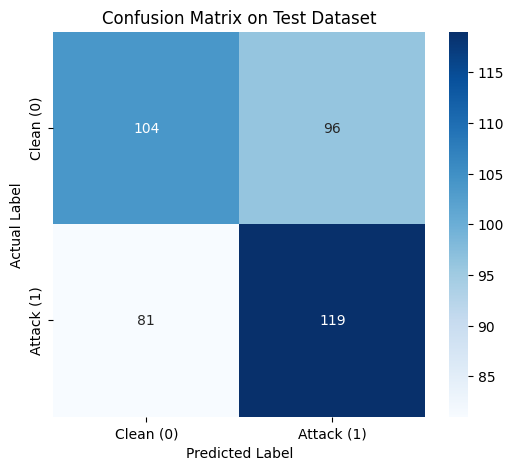

In [53]:
# Rank the results by accuracy (descending)
results.sort(key=lambda x: x['acc'], reverse=True)

print("========= ALL COMBINATIONS RANKING =========")
for i, res in enumerate(results[:20]): # Showing top 20 to avoid spamming the console
    print(f"{i+1}. {res['params']} - Accuracy: {res['acc']*100:.2f}%")
print("============================================")

best_run = results[0]
best_model = best_run['model']
best_trainer = best_run['trainer']

print(f"Plotting confusion matrix for the BEST combination: {best_run['params']}")
evaluate_and_plot(best_model, best_trainer, test_ds)

In [11]:
from sklearn.metrics import accuracy_score

# Prepare the dictionaries for the specific classes
clean_dict = {'clean': images_by_class['clean']}
attack_a_dict = {'attack_a': images_by_class['attack_a']}

# Create datasets with an 80/20 train/test split
train_ds, test_ds = create_datasets(clean_dict=clean_dict, attack_dicts=[attack_a_dict])

print(f"Total Train Dataset size: {len(train_ds)}")
print(f"Total Test Dataset size: {len(test_ds)}\n")


# Refined Hyperparameter grid based on top 20 results
# Removing 'small', focusing on 'medium', 'medium_bn' and 'medium_light'
model_sizes = ['medium', 'medium_bn', 'medium_light']
# Focusing on the learning rates that yielded the top results
learning_rates = [1e-3, 1e-4]
# Keeping the best dropouts
dropout_rates_1 = [0.0, 0.2, 0.4]
dropout_rates_2 = [0.0, 0.1]
# Removing SGD as it showed up less often at the very top
optimizers = ['adam', 'adamw', 'rmsprop']
epochs = 50 # Increasing epochs back to 50 since the search space is smaller

results_refined = []

test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

total_runs = len(model_sizes) * len(learning_rates) * len(dropout_rates_1) * len(dropout_rates_2) * len(optimizers)
print(f"Starting Refined Grid Search with {total_runs} total combinations...")

current_run = 0
for size in model_sizes:
    for lr in learning_rates:
        for dr1 in dropout_rates_1:
            for dr2 in dropout_rates_2:
                for opt in optimizers:
                    current_run += 1
                    print(f"[{current_run}/{total_runs}] Size={size}, LR={lr}, Dr1={dr1}, Dr2={dr2}, Opt={opt}")
                    model, trainer = train_model(
                        train_ds, 
                        epochs=epochs, 
                        batch_size=32, 
                        lr=lr, 
                        dropout_rate1=dr1, 
                        dropout_rate2=dr2, 
                        size=size,
                        optimizer_name=opt
                    )
                    
                    # Check accuracy on the test set
                    model.eval()
                    device = next(model.parameters()).device
                    all_preds = []
                    all_labels = []
                    with torch.no_grad():
                        for images, labels in test_loader:
                            outputs = model(images.to(device))
                            preds = (outputs > 0).cpu().numpy()
                            all_preds.extend(preds)
                            all_labels.extend(labels.numpy())
                            
                    test_acc = accuracy_score(all_labels, all_preds)
                    print(f"Result: Test Accuracy = {test_acc*100:.2f}%\n")
                    
                    results_refined.append({
                        'params': f"Size={size}, LR={lr}, Dr1={dr1}, Dr2={dr2}, Opt={opt}",
                        'acc': test_acc,
                        'model': model if test_acc >= max([r['acc'] for r in results_refined] + [0]) else None,
                        'trainer': trainer if test_acc >= max([r['acc'] for r in results_refined] + [0]) else None
                    })

# Rank the results by accuracy (descending)
results_refined.sort(key=lambda x: x['acc'], reverse=True)

print("========= REFINED COMBINATIONS RANKING =========")
for i, res in enumerate(results_refined[:10]):
    print(f"{i+1}. {res['params']} - Accuracy: {res['acc']*100:.2f}%")
print("================================================")

best_run_refined = results_refined[0]
best_model_refined = best_run_refined['model']
best_trainer_refined = best_run_refined['trainer']

print(f"Plotting confusion matrix for the BEST combination: {best_run_refined['params']}")
evaluate_and_plot(best_model_refined, best_trainer_refined, test_ds)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory c:\Users\agata\OneDrive\Pulpit\Studia\ML\machine_learning\anomaly\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Total Train Dataset size: 1600
Total Test Dataset size: 400

Starting Refined Grid Search with 108 total combinations...
[1/108] Size=medium, LR=0.001, Dr1=0.0, Dr2=0.0, Opt=adam


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ features   │ Sequential        │ 23.3 K │ train │     0 │
│ 1 │ classifier │ Sequential        │ 67.7 K │ train │     0 │
│ 2 │ criterion  │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 91.0 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 91.0 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 20                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and

...

┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ features   │ Sequential        │ 23.5 K │ train │     0 │
│ 1 │ classifier │ Sequential        │ 67.7 K │ train │     0 │
│ 2 │ criterion  │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 91.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 91.2 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 23                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\IPython\core\interactiveshell.py:3755: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training the best model with logging enabled to diagnose the 56% accuracy barrier...


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ features   │ Sequential        │ 23.3 K │ train │     0 │
│ 1 │ classifier │ Sequential        │ 67.7 K │ train │     0 │
│ 2 │ criterion  │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 91.0 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 91.0 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 20                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec,
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:317: The number of training 
batches (40) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for 
log_every_n_steps if you want to see logs for the training epoch.

`Trainer.fit` stopped: `max_epochs=50` reached.


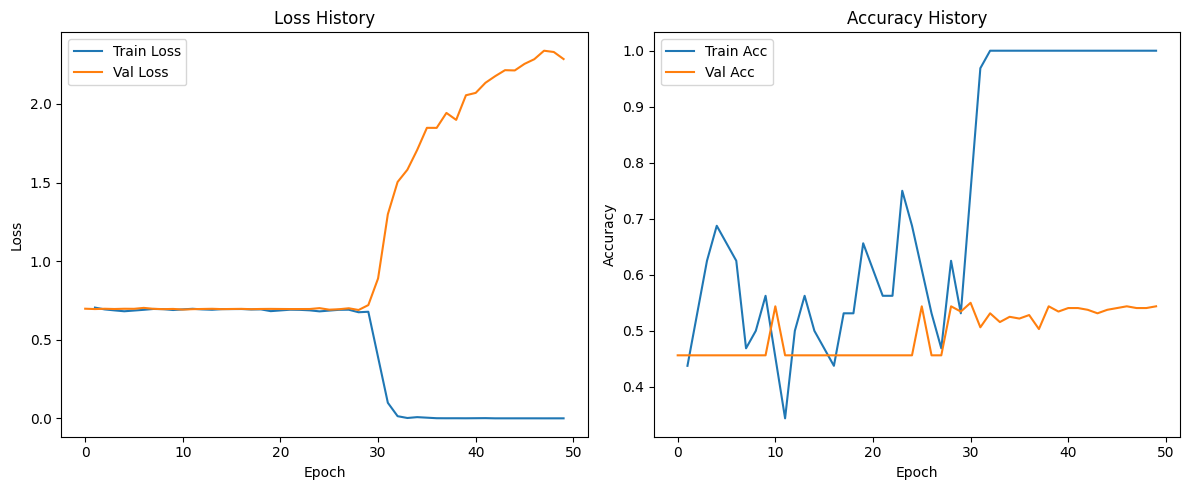

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.5024999976158142     │
│         test_loss         │    2.5478854179382324     │
└───────────────────────────┴───────────────────────────┘

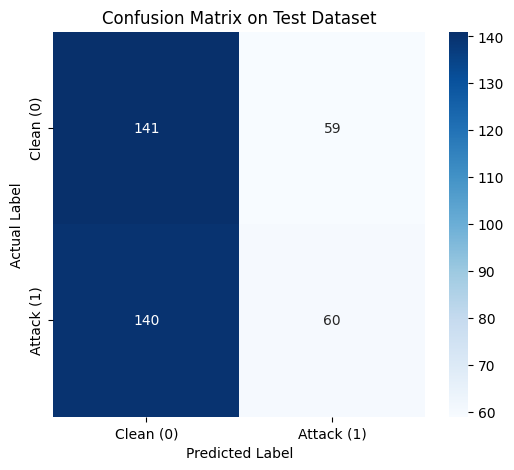

In [10]:
import pandas as pd
from pytorch_lightning.loggers import CSVLogger

# Let's train the absolute best model but this time we will log the training history
# to see if the model is actually learning anything on the training set (Overfitting vs Underfitting)

print("Training the best model with logging enabled to diagnose the 56% accuracy barrier...")

size = 'medium'
lr = 0.001
dr1 = 0.2
dr2 = 0.1
opt = 'adam'
epochs = 50

best_model_for_debugging = VariableCNN(size=size, lr=lr, dropout_rate1=dr1, dropout_rate2=dr2, optimizer_name=opt)

# Re-split to be sure
train_size = int(0.8 * len(train_ds))
val_size = len(train_ds) - train_size
train_split, val_split = random_split(train_ds, [train_size, val_size])

train_loader_debug = DataLoader(train_split, batch_size=32, shuffle=True, num_workers=0)
val_loader_debug = DataLoader(val_split, batch_size=32, shuffle=False, num_workers=0)

# Use CSVLogger to capture loss and accuracy per epoch
logger = CSVLogger("logs", name="debug_best_model")

trainer_debug = pl.Trainer(
    max_epochs=epochs,
    accelerator='auto',
    devices='auto',
    logger=logger,
    enable_progress_bar=True
)

trainer_debug.fit(best_model_for_debugging, train_loader_debug, val_loader_debug)

# Read the logged metrics
metrics = pd.read_csv(f"{logger.log_dir}/metrics.csv")

# Plot the training and validation history
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
if 'train_loss' in metrics.columns:
    train_loss = metrics[['epoch', 'train_loss']].dropna()
    plt.plot(train_loss['epoch'], train_loss['train_loss'], label='Train Loss')
if 'val_loss' in metrics.columns:
    val_loss = metrics[['epoch', 'val_loss']].dropna()
    plt.plot(val_loss['epoch'], val_loss['val_loss'], label='Val Loss')
plt.title('Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
if 'train_acc' in metrics.columns:
    train_acc = metrics[['epoch', 'train_acc']].dropna()
    plt.plot(train_acc['epoch'], train_acc['train_acc'], label='Train Acc')
if 'val_acc' in metrics.columns:
    val_acc = metrics[['epoch', 'val_acc']].dropna()
    plt.plot(val_acc['epoch'], val_acc['val_acc'], label='Val Acc')
plt.title('Accuracy History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate on test set
evaluate_and_plot(best_model_for_debugging, trainer_debug, test_ds)
